In [76]:
import numpy as np
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import cornerplot

In [77]:
from src.noise import add_noise
from src.config import Config
from src.simulation import Simulation
from src.utilities import estimate_neff
from sampling.posterior import FWIPosterior
from src.layers import create_layers_from_interfaces
from src.plot.plot_tools import plot_layered_config, plot_seismogram, set_plot_style
set_plot_style()

In [78]:
seed = 42
np.random.seed(seed)

In [79]:
config = Config(
        n_receivers=16,
        x_min=0.0,
        x_max=1500.0,
        z_rec=80.0,
        z_src=40.0,
        x_src=50.0,
        nq_prop=64,
        nq_evan=64,
        f0=10.0,
        total_time=1.024,
        delay=0.1,
        epsilon=1.5,
        free_surface=False,
        nfft_pad_factor=2,
        source_deriv=False,
        ind_traces=[],
    )

In [80]:
vp_true = np.array([1500.0, 3500.0, 1800.0, 2300.0, 4000.0])
z_int = np.array([0.0, 100.0, 250.0, 400.0, 450.0, 700.])
rho = np.array([2000.0, 2000.0, 2000.0, 2000.0, 2000.0])

layers = create_layers_from_interfaces(z_int, vp_true, rho)
sim = Simulation(config)

In [81]:
d_clean, _ = sim.forward(layers)
d_obs, std_noise = add_noise(d_clean.squeeze(), noise_level=0.12, seed=seed)

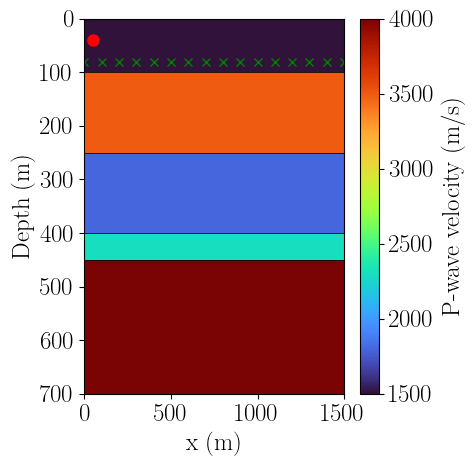

In [82]:
plot_layered_config(layers, xrecvs=sim.acq.xr, zrecvs=sim.acq.zr[0], xs=[sim.acq.xs, sim.acq.zs], cmap='turbo')

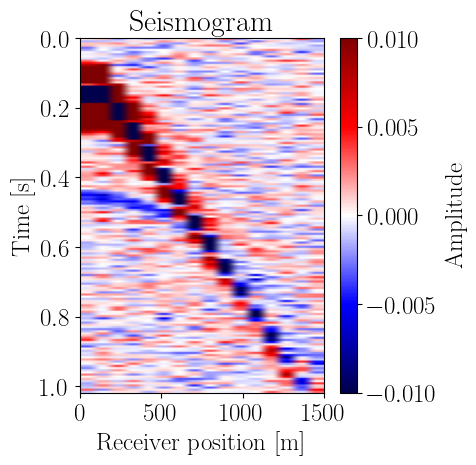

In [83]:
plot_seismogram(d_obs.T, sim.acq.xr, sim.param.time, vmin=-0.01, vmax=0.01, ncolors=256, figsize=(5,5))

In [84]:
# prior mean and covariance for the velocities
mu = np.array([3000.0, 3000.0, 3000.0, 3000.0])
cov = np.diag([700**2, 800**2, 1000**2, 1000**2])
result = estimate_neff(d_obs)
beta = result['n_eff'] / d_obs.size
print(beta)
# Initialize the posterior object
bayes = FWIPosterior(
    d_obs,
    layers,
    sim,
    mu,
    cov,
    std_noise=float(std_noise),
    beta=float(beta), # normalize by the number of data points
)

0.18158301577192762


In [85]:
from scipy.stats import truncnorm
def prior_transform(cube):
    """
    Maps UltraNest's [0, 1] unit cube to Gaussian priors for the layer velocities, truncated to a reasonable range.
    """
    # Bounds for Vp
    v_min, v_max = 1000.0, 7000.0
    mu = bayes.mu
    sigma = np.sqrt(np.diag(bayes.cov))
    a_scaled = (v_min - mu) / sigma
    b_scaled = (v_max - mu) / sigma
    # Map the entire cube in one shot
    return truncnorm.ppf(cube, a_scaled, b_scaled, loc=mu, scale=sigma)

def log_likelihood(params):
    return bayes.log_likelihood(params)


In [86]:
param_names = [f"Vp_{i+1}" for i in range(len(vp_true[1:]))]

sampler = ultranest.ReactiveNestedSampler(
    param_names,
    log_likelihood,
    prior_transform,
)

In [87]:
result = sampler.run(min_ess=500, min_num_live_points=300)
sampler.print_results()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=2e+02  3 [156.0012..156.0016]*| it/evals=3831/14202 eff=27.5572% N=300 
[ultranest] Likelihood function evaluations: 14203
[ultranest]   logZ = 147.9 +- 0.1117
[ultranest] Effective samples strategy satisfied (ESS = 1592.2, need >500)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.11 tail:0.01 total:0.11 required:<0.50
[ultranest] done iterating.

logZ = 147.877 +- 0.250
  single instance: logZ = 147.877 +- 0.145
  bootstrapped   : logZ = 147.906 +- 0.250
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    Vp_1                : 3114  │ ▁   ▁▁▁▁▁▁▁▂▃▄▅▅▇▇▇▇▆▆▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁ │3818      3470 +- 80
    Vp_2                : 1370  │ ▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▆▅▇▆▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁  ▁ │2491      1862 +- 136
    Vp_3                : 1449  │ ▁▁▁▁▁▁▂▃▃▅

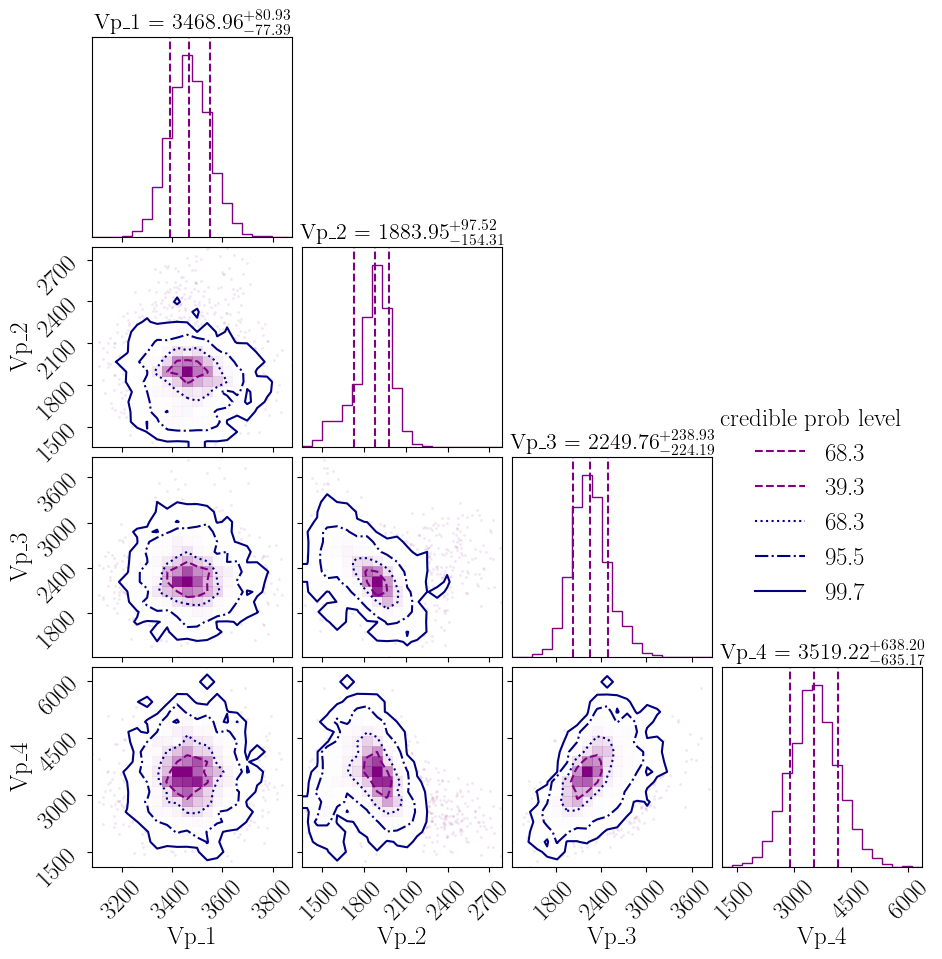

In [97]:
figure = cornerplot(result, plot_density=True, title_kwargs={"fontsize": 16}, plot_datapoints=True)
plt.show()

In [89]:
from ultranest.plot import PredictionBand
band2 = PredictionBand(sim.param.time)
band6 = PredictionBand(sim.param.time)
band12 = PredictionBand(sim.param.time)
ns = len(sampler.results['samples'])
# go through the solutions
for vp1, vp2, vp3, vp4 in sampler.results['samples'][0:ns:10]:
    # compute for each time the y value
    VP = np.array([vp_true[0], vp1, vp2, vp3, vp4])
    lays = create_layers_from_interfaces(z_int, VP, rho)
    d_cal = sim.forward(lays)[0]
    band2.add(d_cal[0, 2, :])
    band6.add(d_cal[0, 6, :])
    band12.add(d_cal[0, 12, :])

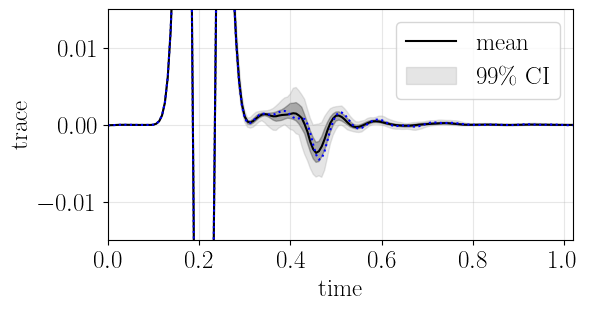

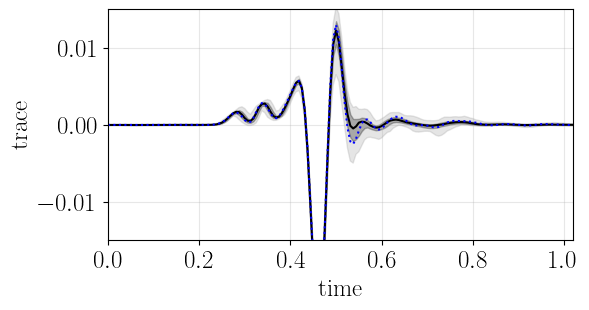

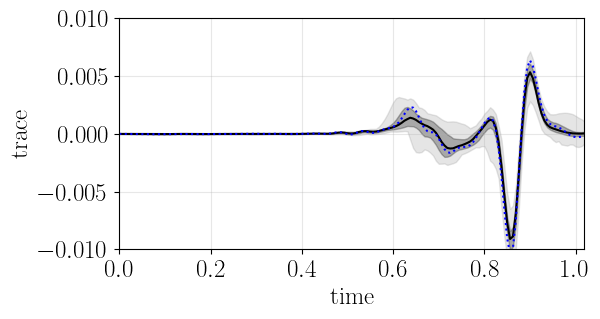

In [93]:
d_ref = d_clean.squeeze()
# plot prediction bands for trace 1
plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band2.line(color='k', label='mean')
band2.shade(color='k', alpha=0.3)
band2.shade(q=0.495, color='gray', alpha=0.2, label='99\% CI')
plt.plot(sim.param.time, d_ref[2], 'b:')
plt.ylim([-0.015,0.015])
plt.xlim([0.0, sim.param.time[-1]])
plt.grid(alpha=0.3)
plt.legend()

# plot prediction bands for trace 4
plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band6.line(color='k')
band6.shade(color='k', alpha=0.3)
band6.shade(q=0.495, color='gray', alpha=0.2)
plt.plot(sim.param.time, d_ref[6], 'b:')
plt.ylim([-0.015,0.015])
plt.xlim([0.0, sim.param.time[-1]])
plt.grid(alpha=0.3)

# plot prediction bands for trace 15
plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band12.line(color='k')
band12.shade(color='k', alpha=0.3)
band12.shade(q=0.495, color='gray', alpha=0.2)
plt.plot(sim.param.time, d_ref[12], 'b:')
plt.ylim([-0.01,0.01])
plt.xlim([0.0, sim.param.time[-1]])
plt.grid(alpha=0.3)